# Beautified cumulative-through-time maps + GIF (Baltic region)

This notebook:
- reads an iNaturalist CSV export (your uploaded `observations-664172.csv`),
- reads the export bounds from the accompanying README,
- filters observations to that bounding box,
- renders a **high-DPI** cumulative scatter map for each year,
- builds an animated **GIF** and a final still figure.

Export metadata (including the bounding-box query) comes from your README. fileciteturn3file0L1-L12


In [29]:
from pathlib import Path
import re
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
import matplotlib.pyplot as plt
import imageio.v2 as imageio

# --------------------
# INPUTS (edit if needed)
# --------------------
CSV_CANDIDATES = [
    Path('data/aureoboletus_projectullus/observations-664172.csv'),
    Path('/data/aureoboletus_projectullus/observations-664172.csv'),
]
CSV_PATH = next((p for p in CSV_CANDIDATES if p.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError('Could not find observations-664172.csv. Put it next to the notebook or edit CSV_PATH.')

README_CANDIDATES = [
    Path('data/aureoboletus_projectullus/README.txt'),
    Path('/data/aureoboletus_projectullus/README.txt'),
]
README_PATH = next((p for p in README_CANDIDATES if p.exists()), None)
if README_PATH is None:
    raise FileNotFoundError('Could not find README.txt. Put it next to the notebook or edit README_PATH.')

# --------------------
# OUTPUTS
# --------------------
OUTDIR = Path('outputs/baltic_beautified')
FRAMES_DIR = OUTDIR / 'frames'
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

FINAL_FIG_PATH = OUTDIR / 'final_year.png'
GIF_PATH = OUTDIR / 'cumulative.gif'

# --------------------
# STYLE KNOBS ("beautify" controls)
# --------------------
DPI = 240
FIGSIZE = (10.0, 8.0)

# Points
HIGHLIGHT_NEW = True
S_OLD = 25         # marker size for older cumulative points
S_NEW = 35         # marker size for points first appearing in a year
ALPHA_OLD = 0.70
ALPHA_NEW = 0.90

# Colors (explicit because you asked to beautify)
LAND_COLOR = '#f3efe3'
WATER_COLOR = '#eaf2f8'
BORDER_COLOR = '#6c7a89'
POINT_OLD_COLOR = "#0080ffff"
POINT_NEW_COLOR = '#c0392b'

# GIF settings
FPS = 3
HOLD_LAST_N_FRAMES = 5  # pause on the final year

# Map projection (good for Europe)
TARGET_CRS = 'EPSG:3035'  # ETRS89 / LAEA Europe

# If you have a huge dataset, you can subsample cumulative points per frame (None = no subsample)
MAX_POINTS_PER_FRAME = None


In [30]:
# Parse the bbox from README query
readme_txt = README_PATH.read_text(encoding='utf-8', errors='ignore')

def _extract_float(key: str, text: str) -> float:
    m = re.search(rf"{key}=([0-9\.-]+)", text)
    if not m:
        raise ValueError(f"Could not find '{key}=' in README query")
    return float(m.group(1))

swlat = _extract_float('swlat', readme_txt)
swlng = _extract_float('swlng', readme_txt)
nelat = _extract_float('nelat', readme_txt)
nelng = _extract_float('nelng', readme_txt)

LAT_MIN, LAT_MAX = swlat, nelat
LON_MIN, LON_MAX = swlng, nelng

print('Using bbox from README:')
print('  LAT:', LAT_MIN, 'to', LAT_MAX)
print('  LON:', LON_MIN, 'to', LON_MAX)

# OPTIONAL: tighten to the Baltic states only by uncommenting below
# LAT_MIN, LAT_MAX = 53.8, 59.9
# LON_MIN, LON_MAX = 20.5, 28.3
# print('Tightened bbox to Baltic states only.')


Using bbox from README:
  LAT: 42.46014020951634 to 68.73847374823592
  LON: -2.9008137554666247 to 40.51715499453337


In [31]:
# Load observations CSV
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print('Loaded:', CSV_PATH)
print('Shape:', df_raw.shape)
display(df_raw.head())

if len(df_raw) == 0:
    raise ValueError('CSV has 0 rows (headers-only). Re-export from iNaturalist and try again.')


Loaded: data/aureoboletus_projectullus/observations-664172.csv
Shape: (294, 7)


,id,time_observed_at,user_id,user_name,latitude,longitude,scientific_name
0,16450375,2018-09-12 13:58:36 UTC,737697,Tomas Pocius,55.927269,21.058508,Aureoboletus projectellus
1,16873459,2018-09-16 07:18:21 UTC,281423,Almantas Kulbis,55.340040,21.025852,Aureoboletus projectellus
2,17230791,2018-09-25 10:22:00 UTC,1244231,Arūnas Juknevičius,54.892014,24.953699,Aureoboletus projectellus
3,32221127,2019-09-05 12:23:31 UTC,2146224,NaN,55.745025,8.251990,Aureoboletus projectellus
4,32221348,2019-09-05 08:43:32 UTC,2146224,NaN,55.761578,8.213150,Aureoboletus projectellus


In [32]:
# Standardize date + coordinates
df = df_raw.copy()

if {'latitude', 'longitude'}.issubset(df.columns):
    df['lat'] = pd.to_numeric(df['latitude'], errors='coerce')
    df['lon'] = pd.to_numeric(df['longitude'], errors='coerce')
elif 'location' in df.columns:
    parts = df['location'].astype(str).str.split(',', n=1, expand=True)
    df['lat'] = pd.to_numeric(parts[0], errors='coerce')
    df['lon'] = pd.to_numeric(parts[1], errors='coerce')
else:
    raise KeyError('Need latitude/longitude columns or a location column ("lat,lon").')

date_col = None
for c in ['time_observed_at', 'observed_on', 'observed_on_string', 'created_at', 'time_created_at']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('Could not find a usable date column (e.g., time_observed_at / observed_on).')

df['date'] = pd.to_datetime(df[date_col], errors='coerce', utc=True)
df = df.dropna(subset=['lat', 'lon', 'date']).copy()
df['year'] = df['date'].dt.year.astype(int)

# Filter to bbox
df = df[df['lat'].between(LAT_MIN, LAT_MAX) & df['lon'].between(LON_MIN, LON_MAX)].copy()
print('After cleaning + bbox filter:', df.shape)
print('Year range:', int(df['year'].min()), '→', int(df['year'].max()))

taxa = sorted(df['scientific_name'].dropna().unique().tolist()) if 'scientific_name' in df.columns else []
taxon_label = taxa[0] if len(taxa) == 1 else ('Multiple taxa' if len(taxa) > 1 else 'Unknown taxon')
print('Taxon label:', taxon_label)

display(df[['date','year','lat','lon']].head())

if len(df) == 0:
    raise ValueError('No rows remain after bbox filter. Adjust bounds or re-export with the desired region.')


After cleaning + bbox filter: (276, 11)
Year range: 2015 → 2025
Taxon label: Aureoboletus projectellus


,date,year,lat,lon
0,2018-09-12 13:58:36+00:00,2018,55.927269,21.058508
1,2018-09-16 07:18:21+00:00,2018,55.340040,21.025852
2,2018-09-25 10:22:00+00:00,2018,54.892014,24.953699
3,2019-09-05 12:23:31+00:00,2019,55.745025,8.251990
4,2019-09-05 08:43:32+00:00,2019,55.761578,8.213150


year
2015      1
2016      1
2017      1
2018      5
2019      3
2020     11
2021     16
2022      8
2023     63
2024     59
2025    108
dtype: int64

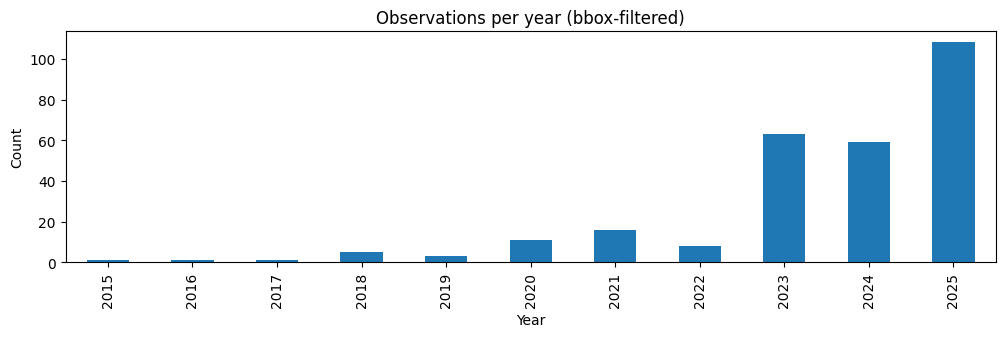

In [33]:
# Quick per-year counts
year_counts = df.groupby('year').size().sort_index()
display(year_counts)
ax = year_counts.plot(kind='bar', figsize=(12,3), title='Observations per year (bbox-filtered)')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
plt.show()


In [34]:
# Build GeoDataFrames + basemap
gdf_obs = gpd.GeoDataFrame(
    df,
    geometry=[Point(xy) for xy in zip(df['lon'], df['lat'])],
    crs='EPSG:4326'
)

world = gpd.read_file("https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson")
bbox_geom = box(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX)

# Clip countries to bbox (in WGS84), then project
world_clip = world[world.intersects(bbox_geom)].copy()
world_clip = world_clip.to_crs(TARGET_CRS)
gdf_obs_proj = gdf_obs.to_crs(TARGET_CRS)

# Compute plot extent from projected bbox
bbox_proj = gpd.GeoSeries([bbox_geom], crs='EPSG:4326').to_crs(TARGET_CRS).iloc[0]
XMIN, YMIN, XMAX, YMAX = bbox_proj.bounds

years = list(range(int(df['year'].min()), int(df['year'].max()) + 1))
print('Frames for years:', years[0], '→', years[-1], f"({len(years)} frames)")


Frames for years: 2015 → 2025 (11 frames)


In [35]:
def plot_frame(year: int, save_path: Path | None = None):
    d_cum = gdf_obs_proj[gdf_obs_proj['year'] <= year]
    d_new = gdf_obs_proj[gdf_obs_proj['year'] == year]

    if MAX_POINTS_PER_FRAME is not None and len(d_cum) > MAX_POINTS_PER_FRAME:
        d_cum = d_cum.sample(MAX_POINTS_PER_FRAME, random_state=0)

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    ax.set_facecolor(WATER_COLOR)
    fig.patch.set_facecolor('white')

    # Basemap
    world_clip.plot(ax=ax, color=LAND_COLOR, edgecolor=BORDER_COLOR, linewidth=0.7, zorder=1)

    # Cumulative points (old)
    ax.scatter(
        d_cum.geometry.x,
        d_cum.geometry.y,
        s=S_OLD,
        alpha=ALPHA_OLD,
        c=POINT_OLD_COLOR,
        linewidths=0,
        zorder=2,
        label='Cumulative observations'
    )

    # New points for the year
    if HIGHLIGHT_NEW:
        ax.scatter(
            d_new.geometry.x,
            d_new.geometry.y,
            s=S_NEW,
            alpha=ALPHA_NEW,
            c=POINT_NEW_COLOR,
            linewidths=0.25,
            edgecolors='white',
            zorder=3,
            label=f'New in {year}'
        )

    # Extent + clean axes
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    n_cum = int((df['year'] <= year).sum())
    n_new = int((df['year'] == year).sum())

    # Title block
    ax.set_title(
        f"{taxon_label} — cumulative iNaturalist observations through {year}",
        fontsize=15,
        pad=14,
    )
    ax.text(
        0.5, 1.01,
        f"Cumulative n={n_cum:,} (new in {year}: {n_new:,})",
        transform=ax.transAxes,
        ha='center', va='bottom',
        fontsize=10,
        color='#2c3e50',
        alpha=0.9,
    )

    # Caption / provenance
    caption = (
        "Data: iNaturalist export (research-grade, verifiable). "
        f"BBox: lat {LAT_MIN:.2f}–{LAT_MAX:.2f}, lon {LON_MIN:.2f}–{LON_MAX:.2f}. "
        f"Projection: {TARGET_CRS}."
    )
    ax.text(
        0.01, 0.01, caption,
        transform=ax.transAxes,
        fontsize=8.5,
        va='bottom', ha='left',
        color='#2c3e50',
        alpha=0.85,
    )

    # Legend (small, unobtrusive)
    leg = ax.legend(
        loc='upper left',
        frameon=True,
        framealpha=0.85,
        fontsize=9,
        borderpad=0.6,
    )
    leg.get_frame().set_linewidth(0.0)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches='tight')
        plt.close(fig)
    return fig


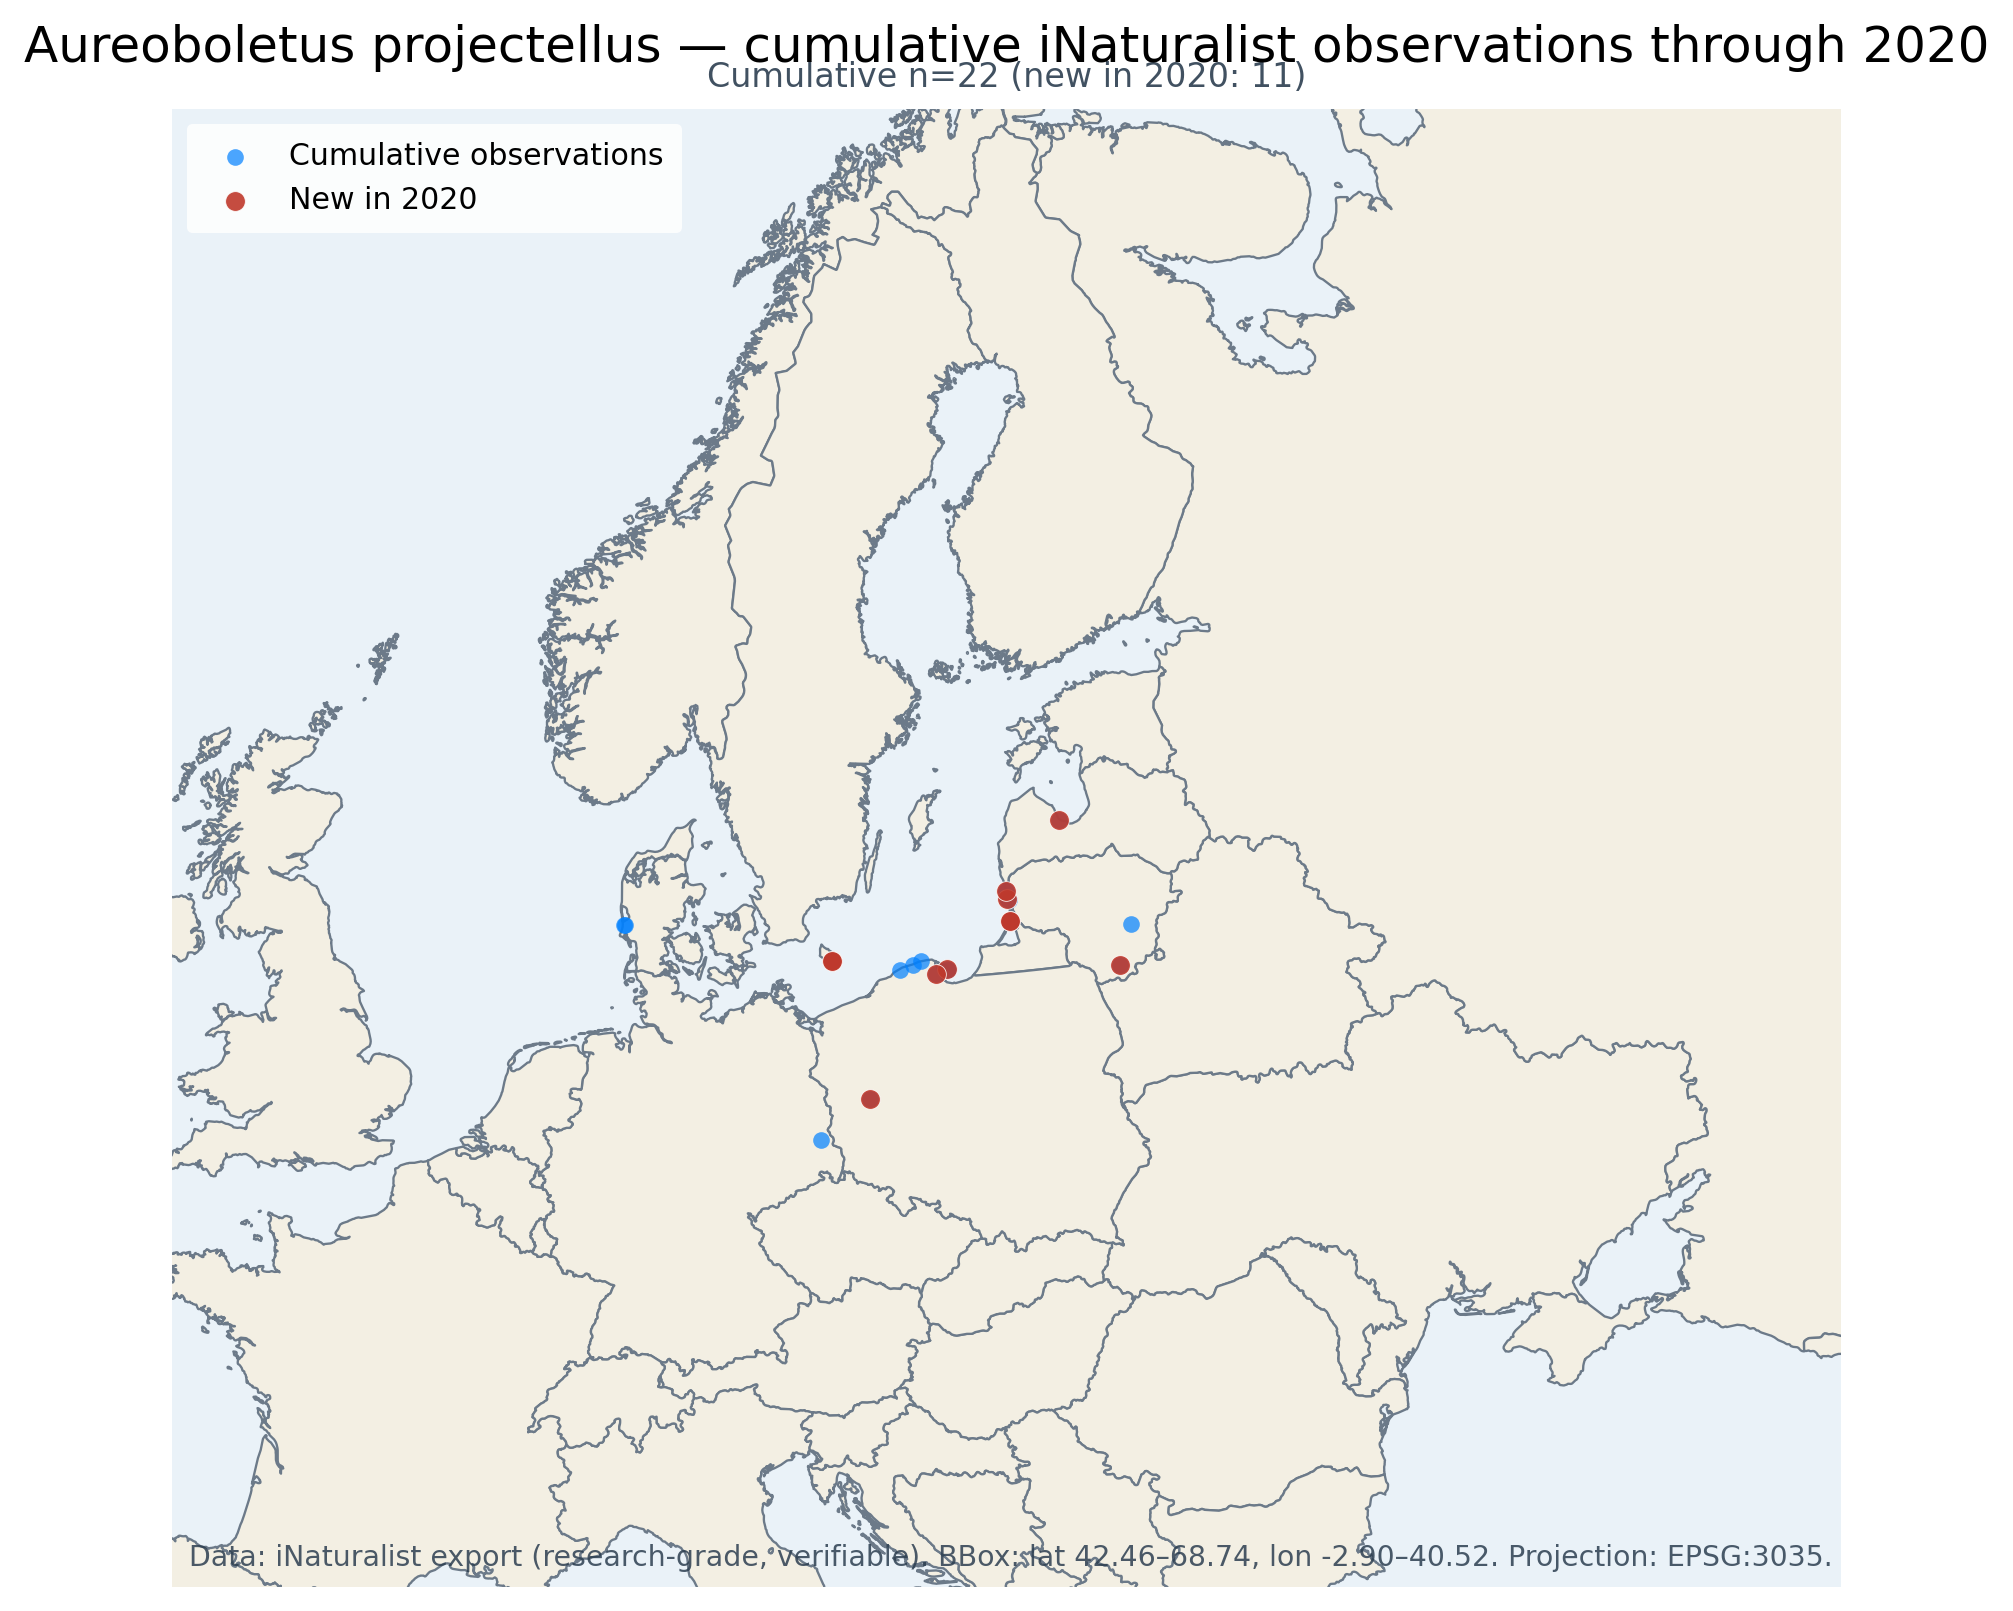

In [36]:
# Preview a mid-series frame
mid_year = years[len(years)//2]
fig = plot_frame(mid_year)
plt.show()


In [37]:
# Render PNG frames
frame_paths = []
for y in years:
    p = FRAMES_DIR / f"frame_{y}.png"
    plot_frame(y, save_path=p)
    frame_paths.append(p)

print('Wrote', len(frame_paths), 'frames to', FRAMES_DIR.resolve())
frame_paths[:3], frame_paths[-3:]


Wrote 11 frames to /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/baltic_beautified/frames


([PosixPath('outputs/baltic_beautified/frames/frame_2015.png'),
  PosixPath('outputs/baltic_beautified/frames/frame_2016.png'),
  PosixPath('outputs/baltic_beautified/frames/frame_2017.png')],
 [PosixPath('outputs/baltic_beautified/frames/frame_2023.png'),
  PosixPath('outputs/baltic_beautified/frames/frame_2024.png'),
  PosixPath('outputs/baltic_beautified/frames/frame_2025.png')])

In [38]:
# Write a final-year still (high resolution)
plot_frame(years[-1], save_path=FINAL_FIG_PATH)
print('Wrote final figure:', FINAL_FIG_PATH.resolve())


Wrote final figure: /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/baltic_beautified/final_year.png


In [39]:
# Build GIF (with a pause on the final frame)
frames = [imageio.imread(p) for p in frame_paths]
if HOLD_LAST_N_FRAMES and HOLD_LAST_N_FRAMES > 0:
    frames.extend([frames[-1]] * HOLD_LAST_N_FRAMES)

imageio.mimsave(GIF_PATH, frames, fps=FPS, loop=0)
print('Wrote GIF:', GIF_PATH.resolve())


Wrote GIF: /Users/jasonraiti/Documents/GitHub/iNat-Mapping/outputs/baltic_beautified/cumulative.gif


## Notes / common tweaks

1) **Make it more "Baltic-only"** (Estonia/Latvia/Lithuania): uncomment the tighter bbox in the bbox cell.

2) **If the GIF looks visually noisy**:
- decrease `ALPHA_OLD` (e.g., 0.10)
- keep `HIGHLIGHT_NEW=True`
- reduce `S_OLD`

3) **If you want a cleaner “spread” story**:
- keep old points faint, new points bold (already the default)
- optionally use an additional inset plot showing cumulative n over time (we can add this if you want).
